# 이미지 캡션 기반 멀티모달 RAG

RAG(Retrieval-Augmented Generation)는 먼저 관련 근거를 검색하고 그 근거를 사용해 답변을 만드는 방식이다. 이 노트북은 이미지를 BLIP 캡션으로 바꾸고, 캡션 embedding과 질문 embedding의 cosine similarity를 직접 계산해 관련 이미지를 검색한다. 검색된 캡션과 원본 이미지 경로는 짧은 템플릿 답변의 근거가 된다.

이 방식은 이미지를 설명 문장으로 바꿔 텍스트 embedding 검색을 적용한다. 그러나 캡션에서 빠진 색상, 위치, 작은 객체는 검색할 수 없다. 이미지 자체를 embedding하는 CLIP 검색이나 검색된 이미지를 VLM에 다시 입력하는 방식과는 다른 **캡션 기반 RAG**이다.

## 전체 처리 흐름

검색 자료 준비 단계에서는 이미지마다 캡션과 embedding을 만든다. 검색 단계에서는 질문 embedding과 모든 캡션 embedding의 cosine similarity를 계산하고, 점수가 높은 record와 연결된 원본 이미지를 찾는다.

```mermaid
flowchart TD
    subgraph INDEX["1. 검색 자료 준비"]
        A["원본 이미지"] --> B["BLIP<br/>영어 캡션 생성"]
        B --> C["이미지 캡션"]
        C --> D["SentenceTransformer"]
        D --> E["384차원 캡션 embedding"]
        C --> F["검색 record 목록"]
        E --> F
        A --> G["이미지 경로·출처 URL"]
        G --> F
    end

    subgraph SEARCH["2. 검색과 답변 단계"]
        Q["사용자의 영어 질문"] --> H["같은 SentenceTransformer"]
        H --> I["질문 embedding"]
        I --> J["cosine similarity 계산"]
        J --> K["점수 내림차순 정렬"]
        K --> M["top-k record 선택"]
        M --> N["원본 이미지 확인"]
        M --> O["근거를 포함한 템플릿 답변"]
    end

    E --> J
    F --> M
```

현재 generation 단계는 LLM을 호출하지 않고 cosine similarity로 선택한 최상위 캡션과 이미지 경로를 템플릿에 넣는다.

## 실행 환경과 패키지

다음 명령은 노트북을 실행할 환경에서 한 번만 수행한다. `torch`는 현재 GPU와 CUDA 환경에 설치된 버전을 그대로 사용한다.

```bash
python -m pip install transformers==4.56.2 sentence-transformers==5.7.0 pillow==12.2.0 requests==2.34.2 matplotlib==3.11.1
```

BLIP와 sentence-transformers 모델을 처음 사용할 때는 인터넷 연결이 필요하다. 모델 다운로드와 첫 추론에는 시간이 필요하다.

In [1]:
%pip install transformers==4.56.2 sentence-transformers==5.7.0 pillow==12.2.0 requests==2.34.2 matplotlib==3.11.1

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\playdata2\miniforge3\envs\llm_env\python.exe -m pip install --upgrade pip


## 공식 예제 이미지 세 개 내려받기

공식 예제 이미지 세 장을 `data/multimodal_rag/images`에 저장한다. 생성한 검색 catalog는 이후 셀에서 `artifacts/multimodal_rag`에 기록한다. 이미 내려받은 파일은 재사용한다.

In [2]:
from pathlib import Path
import requests

IMAGE_DIR = Path("data/multimodal_rag/images")
ARTIFACT_DIR = Path("artifacts/multimodal_rag")
IMAGE_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_SOURCES = [
    {
        "id": "blip_demo",
        "filename": "blip_demo.jpg",
        "url": "https://storage.googleapis.com/sfr-vision-language-research/BLIP/demo.jpg",
    },
    {
        "id": "coco_sample",
        "filename": "coco_sample.png",
        "url": "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/coco_sample.png",
    },
    {
        "id": "transformers_car",
        "filename": "transformers_car.jpg",
        "url": "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/transformers/tasks/car.jpg",
    },
]

for source in IMAGE_SOURCES:
    image_path = IMAGE_DIR / source["filename"]
    if not image_path.exists():
        response = requests.get(source["url"], timeout=30)
        response.raise_for_status()
        image_path.write_bytes(response.content)
    source["image_path"] = image_path
    print(f'{source["id"]}: {image_path}')

blip_demo: data\multimodal_rag\images\blip_demo.jpg
coco_sample: data\multimodal_rag\images\coco_sample.png
transformers_car: data\multimodal_rag\images\transformers_car.jpg


## 이미지 내용과 크기 확인

다운로드 성공 여부만으로는 이미지가 올바르게 열리는지 알 수 없다. 각 파일을 RGB로 읽고 제목에 id와 크기를 표시한다. 이 세 이미지가 뒤에서 BLIP의 입력이 되므로 손상된 파일이나 예상과 다른 이미지는 이 단계에서 발견해야 한다.

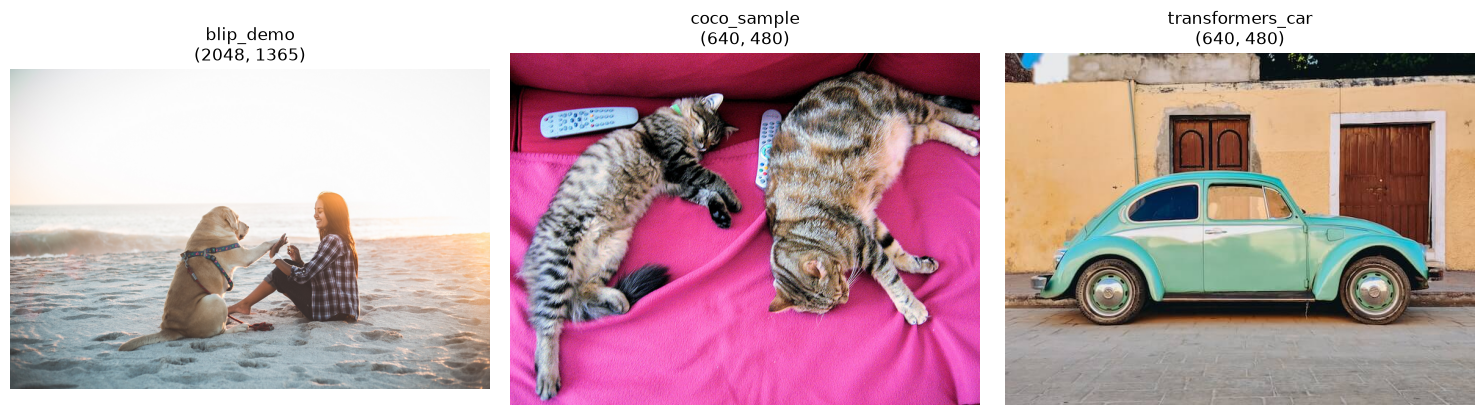

{'blip_demo': (2048, 1365), 'coco_sample': (640, 480), 'transformers_car': (640, 480)}


In [3]:
from PIL import Image
import matplotlib.pyplot as plt

figure, axes = plt.subplots(1, len(IMAGE_SOURCES), figsize=(15, 4))
for axis, source in zip(axes, IMAGE_SOURCES):
    sample_image = Image.open(source["image_path"]).convert("RGB")
    source["size"] = sample_image.size
    axis.imshow(sample_image)
    axis.set_title(f'{source["id"]}\n{sample_image.size}')
    axis.axis("off")

plt.tight_layout()
plt.show()
print({source["id"]: source["size"] for source in IMAGE_SOURCES})

## BLIP 이미지 캡셔닝 모델 준비

BLIP(Bootstrapping Language-Image Pre-training)은 이미지와 텍스트를 함께 학습한 vision-language 모델이다. `BlipProcessor`는 이미지를 모델 입력 Tensor로 바꾸고, `BlipForConditionalGeneration`은 이미지 특징을 바탕으로 token을 순차 생성한다. 이 실습은 `Salesforce/blip-image-captioning-base`를 사용해 각 이미지를 영어 한 문장으로 요약한다.

In [4]:
import os
import torch

os.environ["USE_TF"] = "0"
from transformers import BlipForConditionalGeneration, BlipProcessor

BLIP_MODEL_ID = "Salesforce/blip-image-captioning-base"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

caption_processor = BlipProcessor.from_pretrained(
    BLIP_MODEL_ID,
    use_fast=False,
)
caption_model = BlipForConditionalGeneration.from_pretrained(BLIP_MODEL_ID)

caption_model.to(DEVICE)
caption_model.eval()

print(f"model_id={BLIP_MODEL_ID}")
print(f"device={DEVICE}")

model_id=Salesforce/blip-image-captioning-base
device=cpu


## 이미지별 캡션 생성

processor는 RGB 이미지를 `pixel_values` Tensor로 변환한다. `generate(max_new_tokens=30)`은 입력 이미지 뒤에 최대 30개의 새 token을 생성하고, `decode(..., skip_special_tokens=True)`는 특수 token을 제거한 문장으로 복원한다. 결과 레코드에는 검색 문서인 `caption`과 근거를 다시 열 수 있는 상대 이미지 경로를 함께 저장한다.

In [5]:
records = []
for source in IMAGE_SOURCES:
    rgb_image = Image.open(source["image_path"]).convert("RGB")

    # 입력 이미지 -> pixel_values -> PyTorch Tensor 변환
    caption_inputs = caption_processor(
        images=rgb_image,
        return_tensors="pt",
    ).to(DEVICE)

    with torch.inference_mode():
        # 입력 이미지 캡션(Token Ids) 생성
        generated_ids = caption_model.generate(
            **caption_inputs,
            max_new_tokens=30,
        )

    # Token Ids -> 텍스트로 변환
    caption = caption_processor.decode(
        generated_ids[0],
        skip_special_tokens=True,
    ).strip()

    records.append({
        "id": source["id"],
        "caption": caption,
        "image_path": str(source["image_path"]),
        "source_url": source["url"],
    })

for record in records:
    print(f'{record["id"]}: {record["caption"]}')

blip_demo: a woman sitting on the beach with her dog
coco_sample: two cats sleeping on a couch
transformers_car: a green volkswagen beetle parked in front of a yellow building


## 검색 catalog를 JSONL로 저장

JSONL은 한 줄에 하나의 JSON 객체를 저장하는 형식이다. 줄 단위로 레코드를 추가하거나 읽기 쉬워 작은 검색 catalog에 적합하다. `ensure_ascii=False`는 한글이 들어오더라도 읽을 수 있는 문자로 저장하고, UTF-8 encoding은 운영체제에 따른 문자 깨짐을 줄인다.

In [6]:
import json

CATALOG_PATH = ARTIFACT_DIR / "image_catalog.jsonl"

catalog_lines = [
    json.dumps(record, ensure_ascii=False)
    for record in records
]
CATALOG_PATH.write_text("\n".join(catalog_lines) + "\n", encoding="utf-8")

print(f"catalog_path={CATALOG_PATH}")
print(f"record_count={len(catalog_lines)}")

catalog_path=artifacts\multimodal_rag\image_catalog.jsonl
record_count=3


## 캡션 embedding 만들기

embedding은 문장의 의미를 고정 길이 숫자 벡터로 표현한 것이다. `sentence-transformers/all-MiniLM-L6-v2`는 영어 문장의 의미 유사도 비교에 적합한 작은 모델이다. `normalize_embeddings=True`로 각 벡터 길이를 1로 만들면 이후 내적으로 cosine similarity를 계산할 수 있다.

BLIP 캡션과 검색 질문은 영어로 맞춘다. 한국어 질의를 직접 사용하려면 다국어 embedding 모델인 `sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2` 등으로 문서와 질문을 함께 다시 embedding해야 한다.

In [7]:
from sentence_transformers import SentenceTransformer

EMBEDDING_MODEL_ID = "sentence-transformers/all-MiniLM-L6-v2"

embedding_model = SentenceTransformer(
    EMBEDDING_MODEL_ID,
    device=str(DEVICE),
)

captions = [record["caption"] for record in records]
caption_embeddings = embedding_model.encode(
    captions,
    normalize_embeddings=True,
    convert_to_numpy=True,
)

print(f"embedding_model={EMBEDDING_MODEL_ID}")
print(f"caption_embeddings_shape={caption_embeddings.shape}")

embedding_model=sentence-transformers/all-MiniLM-L6-v2
caption_embeddings_shape=(3, 384)


## 직접 계산으로 cosine top-k 원리 확인

질문도 캡션과 같은 모델로 embedding해야 같은 공간에서 비교할 수 있다. 이 실습은 모든 캡션 벡터와 질문 벡터를 직접 곱하고, 점수가 높은 순서로 정렬해 cosine similarity 검색 원리를 확인한다.

In [8]:
QUERY = "Find an image that shows a car on a road."
TOP_K = 2

# 캡션을 임베딩한 모델을 활용해 질문도 임베딩 수행
# -> 그래야지만 코사인 유사도 비교 가능!
query_embedding = embedding_model.encode(
    [QUERY],
    normalize_embeddings=True,
    convert_to_numpy=True,
)[0]

#   (3, D) @ (D, ) == 3개의 유사도 반환
similarities = caption_embeddings @ query_embedding
ranked_indices = sorted(
    range(len(records)),
    key=lambda index: float(similarities[index]),
    reverse=True,
)
retrieved = [
    {**records[index], "score": float(similarities[index])}
    for index in ranked_indices[:TOP_K]
]

print(f"query={QUERY}")
for rank, item in enumerate(retrieved, start=1):
    print(f'{rank}. score={item["score"]:.4f} | {item["id"]} | {item["caption"]}')

query=Find an image that shows a car on a road.
1. score=0.3196 | transformers_car | a green volkswagen beetle parked in front of a yellow building
2. score=0.0442 | blip_demo | a woman sitting on the beach with her dog


## 검색된 이미지 근거 확인

텍스트 점수만 보지 않고 검색된 원본 이미지를 함께 확인해야 캡션의 정보 손실이나 오검색을 발견할 수 있다. 각 그림 제목에는 순위, id와 cosine similarity를 표시한다. 검색 결과가 질문과 맞지 않으면 캡션 품질, embedding 모델과 질문 표현을 순서대로 점검한다.

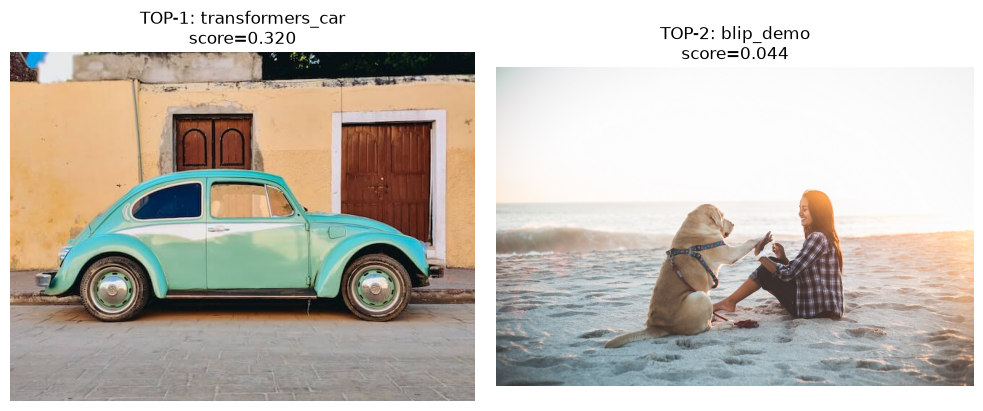

In [9]:
result_figure, result_axes = plt.subplots(1, len(retrieved), figsize=(10, 4))
if len(retrieved) == 1:
    result_axes = [result_axes]

for rank, (axis, item) in enumerate(zip(result_axes, retrieved), start=1):
    result_image = Image.open(Path(item["image_path"])).convert("RGB")
    axis.imshow(result_image)
    axis.set_title(f'TOP-{rank}: {item["id"]}\nscore={item["score"]:.3f}')
    axis.axis("off")

plt.tight_layout()
plt.show()

## 검색 근거를 포함한 템플릿 답변

generation 단계는 검색된 근거를 사용해 사용자에게 전달할 답변을 만드는 단계이다. 여기서는 별도 LLM이나 유료 API를 사용하지 않고 cosine similarity가 가장 높은 record의 id, 캡션, score와 원본 경로를 템플릿에 넣는다. 이 답변은 캡션에 적힌 정보만 사용할 수 있으며 이미지 픽셀을 다시 해석하지 않는다.

In [10]:
top_result = retrieved[0]
answer = (
    f"질문: {QUERY}\n"
    f"답변: 가장 관련 있는 이미지는 '{top_result['id']}'이다. "
    f"BLIP 캡션은 \"{top_result['caption']}\"이다.\n"
    f"근거: cosine similarity={top_result['score']:.4f}, "
    f"image_path={top_result['image_path']}"
)
print(answer)












질문: Find an image that shows a car on a road.
답변: 가장 관련 있는 이미지는 'transformers_car'이다. BLIP 캡션은 "a green volkswagen beetle parked in front of a yellow building"이다.
근거: cosine similarity=0.3196, image_path=data\multimodal_rag\images\transformers_car.jpg


## 캡션 기반 RAG의 한계

현재 실습은 이미지 픽셀이 아니라 BLIP가 생성한 캡션 embedding을 비교한다. 따라서 캡션에 기록되지 않은 작은 객체, 정확한 개수, 글자, 색상과 위치 관계는 질문해도 검색 근거가 되지 않을 수 있다.

시각 정보 자체를 검색하려면 CLIP과 같은 visual embedding을 함께 저장해야 한다. 검색된 이미지를 근거로 더 자세한 답변을 만들려면 해당 이미지를 VLM에 다시 입력해야 한다. 이 두 확장은 현재 캡션 기반 RAG와 입력·처리 방식이 다르다.